# Customer Churn Prediction Using Machine Learning and Explainable AI

## Project Overview

Customer churn refers to the situation where an existing customer stops using a company's products or services. 
For subscription-based businesses such as telecommunications providers, identifying customers who may be at risk 
of leaving can support proactive customer-retention strategies.

This project investigates the development of a machine-learning-based customer churn prediction system. 
The project will compare multiple supervised learning techniques, evaluate their predictive performance using 
appropriate validation and evaluation methods, and investigate the factors contributing to model predictions 
using Explainable AI techniques.

The final prototype will provide churn-risk predictions and supporting explanations that could be used as 
decision-support information for customer-retention teams.

The project will also critically evaluate the limitations, errors, ethical considerations, privacy concerns, 
fairness considerations, and potential societal and business implications of deploying such an AI system in 
a real-world environment.

## Project Objective

The primary objective of this project is to develop and critically evaluate a machine-learning-based customer 
churn prediction prototype that can identify customers at risk of churn, compare suitable AI techniques, 
explain the factors contributing to predictions, and assess the technical, ethical, privacy, and societal 
implications of applying the solution in a real-world customer-retention context.

## Research Questions

This project investigates the following research questions:

1. Which customer characteristics are most strongly associated with customer churn?

2. Which supervised machine-learning approach provides the most effective predictive performance for the 
   customer churn problem?

3. Does hyperparameter optimisation and cross-validation improve the reliability and generalisation of the 
   selected machine-learning models?

4. Can Explainable AI techniques provide meaningful insight into the factors contributing to individual and 
   overall churn predictions?

5. What technical, ethical, privacy, fairness, and societal considerations must be addressed before such a 
   system could be used in a real-world customer-retention environment?

## Methodology

The project will follow a structured machine-learning methodology:

1. Dataset selection and justification
2. Data quality assessment
3. Exploratory Data Analysis (EDA)
4. Data preprocessing
5. Feature engineering
6. Train-test splitting
7. Baseline model development
8. Comparative machine-learning modelling
9. Cross-validation
10. Hyperparameter optimisation
11. Model evaluation
12. Error analysis
13. Explainable AI analysis
14. Customer risk analysis
15. Critical evaluation of limitations and uncertainty
16. Ethical, privacy and societal impact assessment
17. Final prototype and conclusions

The methodology is designed to ensure that the selected dataset, AI techniques, prototype and evaluation 
remain directly connected to the project objective.

## Dataset Selection and Justification

### Selected Dataset

The IBM Telco Customer Churn dataset was selected for this project. The dataset represents
customers of a fictional telecommunications company and contains customer demographic,
service, account and billing information together with a binary churn outcome.

The dataset is appropriate for this project because customer churn is the central prediction
problem being investigated, while the available customer attributes provide sufficient
information for investigating potential relationships between customer characteristics and
churn behaviour.

The dataset also provides a suitable basis for comparing multiple supervised machine-learning
classification techniques and investigating Explainable AI methods.

### Reasons for Selection

The dataset was selected based on the following criteria:

1. **Problem relevance:** The dataset directly represents a customer churn prediction problem,
   which aligns with the project objective.

2. **Feature diversity:** It contains numerical and categorical attributes covering customer
   demographics, service subscriptions, contracts, tenure and billing information.

3. **Machine-learning suitability:** The target variable represents a binary classification
   problem, allowing several supervised learning approaches to be compared.

4. **Explainability:** The features have meaningful business interpretations, allowing model
   predictions to be investigated using Explainable AI techniques.

5. **Data quality challenges:** The dataset contains data-quality issues that provide an
   opportunity to demonstrate systematic data validation and appropriate preprocessing rather
   than relying on an already-clean dataset.

6. **Real-world relevance:** Customer retention and churn prediction are relevant business
   problems, allowing the technical performance of the model to be considered alongside
   business, ethical, privacy and societal implications.

### Dataset Limitations

Although the dataset is suitable for this project, it represents a fictional telecommunications
company and should not be assumed to represent all telecommunications customers or markets.

The dataset is also a historical snapshot. Therefore, a model trained on it may not generalise
perfectly to customers from different geographical regions, organisations, time periods or
changing market conditions.

Consequently, the model developed in this project will be treated as an experimental decision-
support prototype rather than a production-ready system.

### Data Leakage Considerations

Before model development, the dataset will be examined for variables that could introduce
target leakage. Features that directly encode the churn outcome, are generated after the
outcome occurs, or would not realistically be available at the time of prediction will not be
used as predictive inputs.

This is necessary to ensure that model performance reflects genuine predictive capability
rather than information that would not be available in a real-world prediction scenario.

# 1. Data Loading and Initial Validation

This section loads the raw customer churn dataset and performs an initial assessment of its
structure, data types, completeness and consistency.

The purpose of this stage is to understand the characteristics and quality of the dataset
before applying any preprocessing or machine-learning techniques.

No observations will be removed or transformed at this stage. Data-cleaning decisions will
instead be based on the findings from the validation process.

In [1]:
# Core data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Path to the raw dataset
DATA_PATH = "../data/raw/Telco-Customer-Churn.csv"

# Load the dataset
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
# Display the number of rows and columns
rows, columns = df.shape

print(f"Number of records: {rows:,}")
print(f"Number of features/columns: {columns}")

Number of records: 7,043
Number of features/columns: 21


In [4]:
# Display all column names
print("Dataset columns:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:2}. {column}")

Dataset columns:
 1. customerID
 2. gender
 3. SeniorCitizen
 4. Partner
 5. Dependents
 6. tenure
 7. PhoneService
 8. MultipleLines
 9. InternetService
10. OnlineSecurity
11. OnlineBackup
12. DeviceProtection
13. TechSupport
14. StreamingTV
15. StreamingMovies
16. Contract
17. PaperlessBilling
18. PaymentMethod
19. MonthlyCharges
20. TotalCharges
21. Churn


In [5]:
# Display the first five records
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Display the last five records
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [7]:
# Inspect data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
# Count missing values in each column
missing_values = df.isnull().sum()

missing_summary = (
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
)

if missing_summary.empty:
    print("No explicit missing values detected.")
else:
    print("Columns containing explicit missing values:")
    print(missing_summary)

No explicit missing values detected.


In [9]:
# Check for blank or whitespace-only strings in object columns
object_columns = df.select_dtypes(include="object").columns

blank_counts = {}

for column in object_columns:
    blank_count = df[column].astype(str).str.strip().eq("").sum()
    
    if blank_count > 0:
        blank_counts[column] = blank_count

if blank_counts:
    print("Blank/whitespace values detected:")
    for column, count in blank_counts.items():
        print(f"{column}: {count}")
else:
    print("No blank/whitespace-only values detected in categorical/text columns.")

Blank/whitespace values detected:
TotalCharges: 11


C:\Users\bibek\AppData\Local\Temp\ipykernel_29348\1744970839.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes(include="object").columns


In [10]:
# Check for completely duplicated rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicated rows: {duplicate_count}")

Number of duplicated rows: 0


In [11]:
# Check whether customer IDs are unique
duplicate_customer_ids = df["customerID"].duplicated().sum()

print(f"Number of duplicated customer IDs: {duplicate_customer_ids}")

Number of duplicated customer IDs: 0


In [12]:
# Identify numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
for column in numerical_columns:
    print(f"- {column}")

Numerical columns:
- SeniorCitizen
- tenure
- MonthlyCharges


In [13]:
# Statistical summary of numerical variables
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [14]:
# Identify categorical/text columns
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Categorical columns:")
for column in categorical_columns:
    print(f"- {column}")

Categorical columns:
- customerID
- gender
- Partner
- Dependents
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod
- TotalCharges
- Churn


C:\Users\bibek\AppData\Local\Temp\ipykernel_29348\2563794286.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns.tolist()


In [15]:
# Display unique values for categorical variables
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection
<StringArray>
['No', 'Yes', 'No internet service']


In [16]:
# Inspect the target variable
print("Churn value counts:")
print(df["Churn"].value_counts())

print("\nChurn proportions:")
print(df["Churn"].value_counts(normalize=True).round(4))

Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn proportions:
Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64


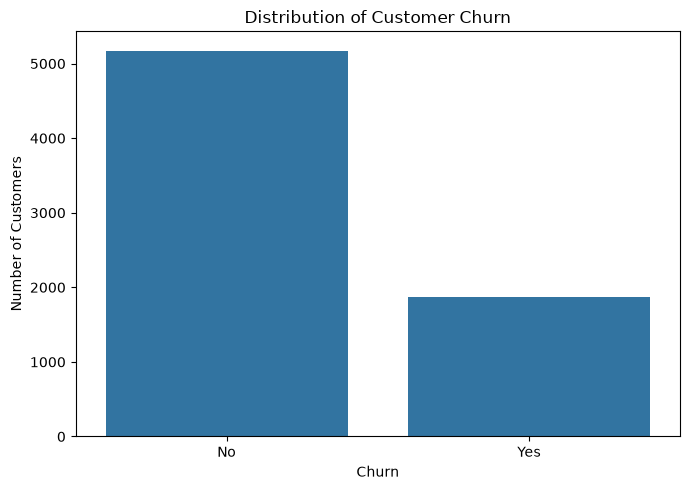

In [17]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [18]:
validation_summary = pd.DataFrame({
    "Metric": [
        "Number of records",
        "Number of columns",
        "Duplicate rows",
        "Duplicate customer IDs",
        "Columns with explicit missing values",
        "Columns with object/text data",
        "Numerical columns"
    ],
    "Value": [
        len(df),
        len(df.columns),
        df.duplicated().sum(),
        df["customerID"].duplicated().sum(),
        (df.isnull().sum() > 0).sum(),
        len(categorical_columns),
        len(numerical_columns)
    ]
})

validation_summary

,Metric,Value
0,Number of records,7043
1,Number of columns,21
2,Duplicate rows,0
3,Duplicate customer IDs,0
4,Columns with explicit missing values,0
5,Columns with object/text data,18
6,Numerical columns,3


## 1.1 Investigation of Data Quality Issues

The initial validation identified 11 blank values in the `TotalCharges` field despite
Pandas reporting no explicit null values.

This indicates that missing information is represented as blank strings rather than
standard missing-value markers.

Rather than immediately removing these observations, the affected records will be
investigated to determine whether the missing values have a meaningful relationship
with other customer attributes, particularly customer tenure and monthly charges.

This approach helps prevent unnecessary data loss and ensures that preprocessing
decisions are supported by evidence.

In [19]:
# Identify records with blank TotalCharges values
blank_total_charges = df[
    df["TotalCharges"].astype(str).str.strip().eq("")
].copy()

print(f"Number of records with blank TotalCharges: {len(blank_total_charges)}")

blank_total_charges[
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

Number of records with blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [20]:
# Inspect the tenure values of customers with blank TotalCharges
blank_total_charges["tenure"].value_counts().sort_index()

tenure
0    11
Name: count, dtype: int64

In [21]:
# Inspect whether the affected customers have churned
blank_total_charges["Churn"].value_counts()

Churn
No    11
Name: count, dtype: int64

In [22]:
# Display the full records for the affected customers
blank_total_charges

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


## 1.2 Handling Missing `TotalCharges` Values

The investigation identified 11 records with blank values in the `TotalCharges` column. 
All 11 records have a customer tenure of zero, indicating that these customers are 
newly registered and have not yet accumulated any charges.

Therefore, the blank values are considered structurally meaningful rather than random 
missing observations. Removing these records would unnecessarily reduce the dataset 
and could introduce bias.

The `TotalCharges` column will first be converted from a string-based field to a 
numeric field, with blank strings converted to missing values. Because the affected 
customers have zero tenure and no accumulated charges, their missing `TotalCharges` 
values will then be represented as 0.0.

This decision preserves all observations while maintaining a logical interpretation 
of the underlying data.

In [23]:
# Convert blank strings to NaN and convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].replace(r"^\s*$", np.nan, regex=True),
    errors="coerce"
)

# Replace missing TotalCharges for zero-tenure customers with 0
df.loc[
    df["TotalCharges"].isna() & (df["tenure"] == 0),
    "TotalCharges"
] = 0.0

print("Missing TotalCharges after preprocessing:")
print(df["TotalCharges"].isna().sum())

print("\nTotalCharges data type:")
print(df["TotalCharges"].dtype)

print("\nZero-tenure records:")
print(df[df["tenure"] == 0][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
])

Missing TotalCharges after preprocessing:
0

TotalCharges data type:
float64

Zero-tenure records:
      customerID  tenure  MonthlyCharges  TotalCharges Churn
488   4472-LVYGI       0           52.55           0.0    No
753   3115-CZMZD       0           20.25           0.0    No
936   5709-LVOEQ       0           80.85           0.0    No
1082  4367-NUYAO       0           25.75           0.0    No
1340  1371-DWPAZ       0           56.05           0.0    No
3331  7644-OMVMY       0           19.85           0.0    No
3826  3213-VVOLG       0           25.35           0.0    No
4380  2520-SGTTA       0           20.00           0.0    No
5218  2923-ARZLG       0           19.70           0.0    No
6670  4075-WKNIU       0           73.35           0.0    No
6754  2775-SEFEE       0           61.90           0.0    No


## 1.3 Categorical Value Consistency

Before performing exploratory analysis and model development, the categorical variables
are checked for unexpected, inconsistent, or incorrectly formatted values.

This validation is important because machine-learning models require categorical values
to be represented consistently. Unexpected categories, spelling differences, or hidden
whitespace could result in incorrect analysis or preprocessing errors.

The unique values of each categorical feature will therefore be examined before proceeding
to feature engineering and model training.

In [24]:
# Identify categorical columns
categorical_columns = df.select_dtypes(
    include=["object", "str"]
).columns

print("Categorical columns:")
print(list(categorical_columns))

print("\nUnique values in each categorical column:\n")

for column in categorical_columns:
    print(f"{column}:")
    print(df[column].unique())
    print()

Categorical columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Unique values in each categorical column:

customerID:
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype

In [25]:
# Check categorical columns for leading or trailing whitespace
print("Whitespace check:\n")

for column in categorical_columns:
    whitespace_count = (
        df[column].astype(str) != df[column].astype(str).str.strip()
    ).sum()
    
    print(f"{column}: {whitespace_count} values with surrounding whitespace")

Whitespace check:

customerID: 0 values with surrounding whitespace
gender: 0 values with surrounding whitespace
Partner: 0 values with surrounding whitespace
Dependents: 0 values with surrounding whitespace
PhoneService: 0 values with surrounding whitespace
MultipleLines: 0 values with surrounding whitespace
InternetService: 0 values with surrounding whitespace
OnlineSecurity: 0 values with surrounding whitespace
OnlineBackup: 0 values with surrounding whitespace
DeviceProtection: 0 values with surrounding whitespace
TechSupport: 0 values with surrounding whitespace
StreamingTV: 0 values with surrounding whitespace
StreamingMovies: 0 values with surrounding whitespace
Contract: 0 values with surrounding whitespace
PaperlessBilling: 0 values with surrounding whitespace
PaymentMethod: 0 values with surrounding whitespace
Churn: 0 values with surrounding whitespace


In [26]:
print("Numerical feature ranges:\n")

print(f"SeniorCitizen: {df['SeniorCitizen'].min()} to {df['SeniorCitizen'].max()}")
print(f"tenure: {df['tenure'].min()} to {df['tenure'].max()}")
print(f"MonthlyCharges: {df['MonthlyCharges'].min()} to {df['MonthlyCharges'].max()}")
print(f"TotalCharges: {df['TotalCharges'].min()} to {df['TotalCharges'].max()}")

Numerical feature ranges:

SeniorCitizen: 0 to 1
tenure: 0 to 72
MonthlyCharges: 18.25 to 118.75
TotalCharges: 0.0 to 8684.8


In [27]:
print("Final missing-value check:")
print(df.isnull().sum())

print("\nTotal missing values in dataset:")
print(df.isnull().sum().sum())

Final missing-value check:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing values in dataset:
0
